# Neural Network Fundamentals and Training Behavior Analysis

## Objective
Build and analyze a feed-forward neural network model for customer churn prediction.

This notebook covers:
- Dataset understanding
- Data preprocessing
- Neural network training
- Model evaluation
- Hyperparameter experimentation
- Neural network learning behavior analysis

In [1]:
#importing necessary libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Task 1: Dataset Understanding

BASIC EXPLORATION

In [ ]:
#importing the dataset
df = pd.read_csv("Data/customer_churn_nn.csv")

df.head(10)

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0
5,CUST0006,North,Premium,One-year,Wallet,13,1058.22,13,1,1,157.49,8.3,115,10,0,1,0
6,CUST0007,Central,Standard,Two-year,Debit Card,38,765.73,18,2,0,119.12,7.1,10,0,1,1,0
7,CUST0008,South,Basic,Month-to-month,UPI,16,327.42,11,5,8,32.46,6.9,99,0,0,0,0
8,CUST0009,South,Premium,Month-to-month,Debit Card,19,1050.49,22,0,2,136.53,6.0,7,20,0,0,0
9,CUST0010,Central,Standard,One-year,Credit Card,20,732.89,14,3,1,115.10,6.4,0,20,0,0,0


In [ ]:
#checking the shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 17)


In [ ]:
print("\nColumn Data Types:\n")
print(df.dtypes)


Column Data Types:

customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [ ]:
#checking for missing values
print("\nMissing Values:\n")
print(df.isna().sum())


Missing Values:

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [ ]:
#Statistical summary of the dataset
print("\nStatistical Summary:\n")
print(df.describe(include="all").T)


Statistical Summary:

                               count unique             top  freq        mean  \
customer_id                     2000   2000        CUST0001     1         NaN   
region                          2000      5            West   417         NaN   
plan_type                       2000      4        Standard   718         NaN   
contract_type                   2000      3  Month-to-month  1111         NaN   
payment_method                  2000      5     Credit Card   411         NaN   
tenure_months                 2000.0    NaN             NaN   NaN      25.362   
monthly_charges_inr           2000.0    NaN             NaN   NaN  766.487295   
avg_login_days_per_month      2000.0    NaN             NaN   NaN      18.099   
support_tickets_last_90_days  2000.0    NaN             NaN   NaN       1.953   
payment_delay_days            2000.0    NaN             NaN   NaN       3.555   
data_usage_gb                 2000.0    NaN             NaN   NaN   90.007625   
satis

TARGET VARIABLE ANALYSIS

In [ ]:
#checking class distribution
print(df["churn"].value_counts())

churn
0    1969
1      31
Name: count, dtype: int64


In [ ]:
#checking class distribution in percentage
print(
    round(
        df["churn"].value_counts(normalize=True) * 100,
        2
    )
)

churn
0    98.45
1     1.55
Name: proportion, dtype: float64


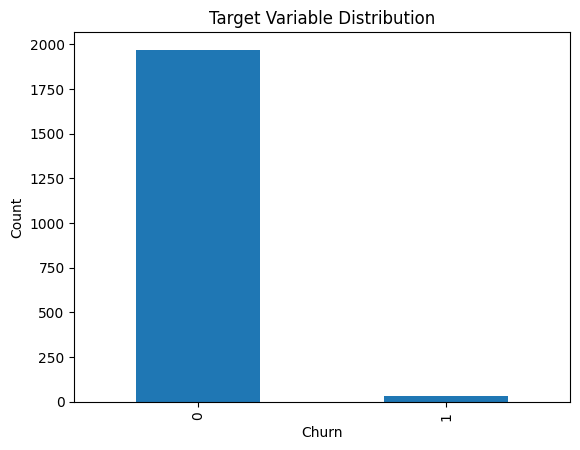

In [ ]:
#visualizing class distribution
df["churn"].value_counts().plot(kind="bar")

plt.title("Target Variable Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

## Task 2: Data Preprocessing

In [ ]:
#Separating features and target variable
X = df.drop(columns=["churn", "customer_id"])
y = df["churn"]

In [ ]:
X = df.drop(columns=["churn", "customer_id"])
y = df["churn"]

In [12]:
categorical_cols = [
    "region",
    "plan_type",
    "contract_type",
    "payment_method"
]

numeric_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

print("Categorical Columns:")
print(categorical_cols)

print("\nNumeric Columns:")
print(numeric_cols)

Categorical Columns:
['region', 'plan_type', 'contract_type', 'payment_method']

Numeric Columns:
['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']


In [ ]:
#Train-test split with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#Creating a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

In [15]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [16]:
print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape:", X_test_processed.shape)

Processed Training Shape: (1600, 28)
Processed Testing Shape: (400, 28)


In [ ]:
#Calculating class weights to handle class imbalance
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = dict(zip(classes, weights))

print(class_weight)

{np.int64(0): np.float64(0.5079365079365079), np.int64(1): np.float64(32.0)}


## Task 3: Neural Network Model Building